# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [240]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [241]:
from google.colab import files
uploaded = files.upload()

insurance_df = pd.read_csv("insurance.csv")
insurance_df.head()


Saving insurance.csv to insurance (10).csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [242]:
insurance_df.shape


(1338, 7)

In [243]:
insurance_df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [244]:
target_variable = "charges"
target_variable


'charges'

# Explanation:
=> Dataset is loaded into a pandas DataFrame.

=> It has multiple features such as 'age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'.

=> The target variable is charges, which represents the medical insurance cost.

=> As the target variable is continuous, this dataset is suitable for regression models.

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


In [245]:
# TODO: Perform EDA
insurance_df.info()

insurance_df.describe()

insurance_df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


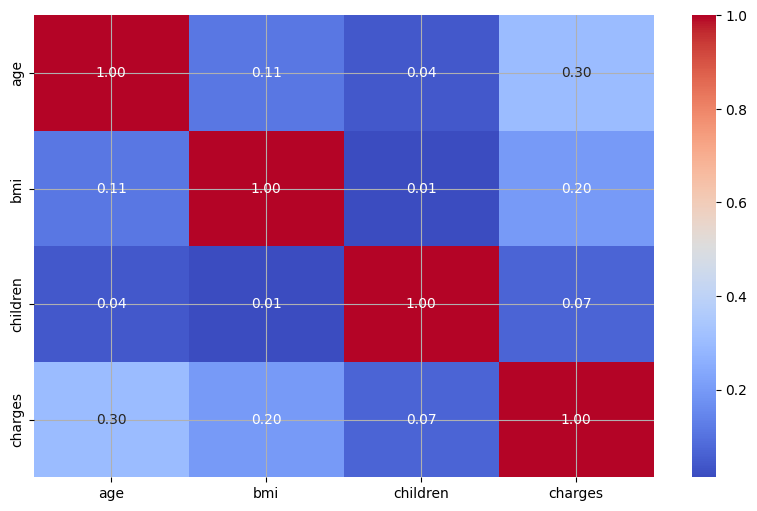

In [246]:
corr = insurance_df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


Explain:

=> Descriptive statistics are used to summarize numerical features, showing their mean, range,max,min, and distribution, outlisers.

=>  Heatmap is plotted to show the relationship between different numerical features and the target variable, helping to identify which features have stronger influence.

=>  Feature vs target visualization (Age vs Charges) is used to observe how insurance charges change with age.

=> It shows a positive relationship between age and insurance charges, cause, both increase parallaly.


## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [247]:
# TODO: Prepare features

from sklearn.model_selection import train_test_split

# Features and target
X = insurance_df.drop("charges", axis=1)
y = insurance_df["charges"]


X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [248]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Explain:

=> It is divided into features (X) and target variable (y), where charges is the target.

Then it is converted into numerical .

=>  The dataset is split into training and testing sets using an 80/20 ratio to evaluate model performance on unseen data.

=> Feature scaling is applied using StandardScaler to normalize feature values so that all features contribute equally to the model.

=>  The scaler is fitted only on the training data and then applied to the test data to avoid data leakage.


## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [249]:
# TODO: Multiple Linear Regression
from sklearn.linear_model import LinearRegression

# Initialize the model
mlr_model = LinearRegression()

# Train the model
mlr_model.fit(X_train_scaled, y_train)


LinearRegression()

In [250]:
# Predict on test data
y_pred = mlr_model.predict(X_test_scaled)


In [251]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 4181.194473753651
RMSE: 5796.284659276274
R² Score: 0.7835929767120722


=>the model makes an error of about 4181.194473753651 in predicting insurance charges.

=>  RMSE being higher than MAE means . So, it give more importance to big error.

=> The R² value 0.7835929767120722 shows that the model explore 78% the variation in the data.

=> So, the model works fairly well for this real world dataset.


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [252]:
# TODO: Polynomial Regression


poly_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear_regression", LinearRegression())
])


poly_model.fit(X_train, y_train)


y_pred_poly = poly_model.predict(X_test)


mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Performance:")
print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R² Score:", r2_poly)


Polynomial Regression Performance:
MAE: 2729.5001336394594
RMSE: 4551.132385233201
R² Score: 0.8665830903164835


In [253]:
print("Linear Regression R²:", r2_score(y_test, y_pred))
print("Polynomial Regression R²:", r2_poly)


Linear Regression R²: 0.7835929767120722
Polynomial Regression R²: 0.8665830903164835


=> So, overall, we can see, Polynomial Regression clearly works better here since its R^2 0.87 is higher than Linear Regression 0.78.

=> MAE ansd RMSE are also lower, so predictions are closer to real values.

=> This means the data has some non linear patterns that polynomial regression captures better than a straight line.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [254]:
# TODO: Support Vector Regression


svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Performance:")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R² Score:", r2_svr)

SVR Performance:
MAE: 8612.408423351833
RMSE: 12889.096314656128
R² Score: -0.07008155372454805


RBF Kernel:  RBF kernel can capture non linear relationships, which exist in real‑world insurance data. Compared to linear kernels, RBF adapts better without manually creating polynomial features.


but in SRV model, MAE and RMSE values more large, it means prediction values are far way from actual values. cause, without proper tuning this dataset will not work well.

Polynomial Regression works much better on this dataset.Even though SVR is a powerful model, without proper parameter tuning it does not perform well on every dataset.
That is why, in this case, Polynomial Regression is more suitable than SVR.


## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [255]:
# TODO: Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Performance:
MAE: 2550.0784706115096
RMSE: 4576.299916157115
R² Score: 0.8651034329144947


The Random Forest model gives more good results overall. MAE and RMSE are lower than Linear and SVR, which means predictions are closer to the actual values.
The R^2 score is around 0.86, so the model explains about 86% of the variance in insurance charges.
Overall, Random Forest performs almost as well as Polynomial Regression and is a strong model for this dataset.

# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [256]:
# TODO: Load classification dataset

from google.colab import files
import pandas as pd
uploaded = files.upload()


loan_df = pd.read_csv("loan_data.csv")

loan_df.head()


Saving loan_data.csv to loan_data (3).csv


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [257]:
#class distribution
loan_df['loan_status'].value_counts()


,count
loan_status,
0,35000
1,10000


This dataset has inequal distribution between the two classes.Class 0 is the majority class, while class 1 is the minority class.This indicates that the dataset is imbalanced.Because of this imbalance, a model can become biased for predicting the majority class more often.

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


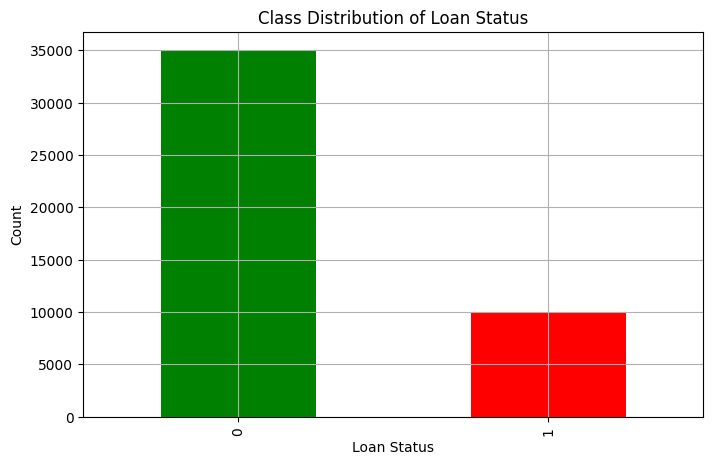

In [258]:
# TODO: Classification EDA

loan_df['loan_status'].value_counts().plot(
    kind='bar',
    color=['green', 'red']
)

plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Class Distribution of Loan Status")
plt.show()

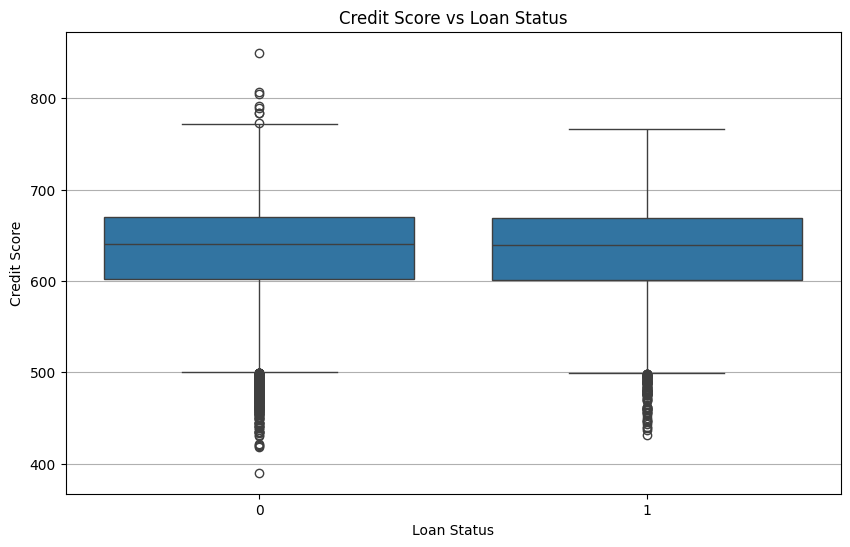

In [259]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='loan_status',
    y='credit_score',
    data=loan_df
)

plt.xlabel("Loan Status")
plt.ylabel("Credit Score")
plt.title("Credit Score vs Loan Status")
plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [260]:
# TODO: Prepare classification features

X = loan_df.drop('loan_status', axis=1)
y = loan_df['loan_status']

#Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [261]:
# TODO: Logistic Regression

log_reg = LogisticRegression(
    penalty='l2',
    max_iter=1000,
    random_state=42
)

# Train model
log_reg.fit(X_train_scaled, y_train)
#prediction
y_pred_lr = log_reg.predict(X_test_scaled)



In [262]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Performance:")
print("Accuracy:", accuracy)
print()

print(classification_report(y_test, y_pred_lr))


Logistic Regression Performance:
Accuracy: 0.8997777777777778

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.85      0.85      9000
weighted avg       0.90      0.90      0.90      9000



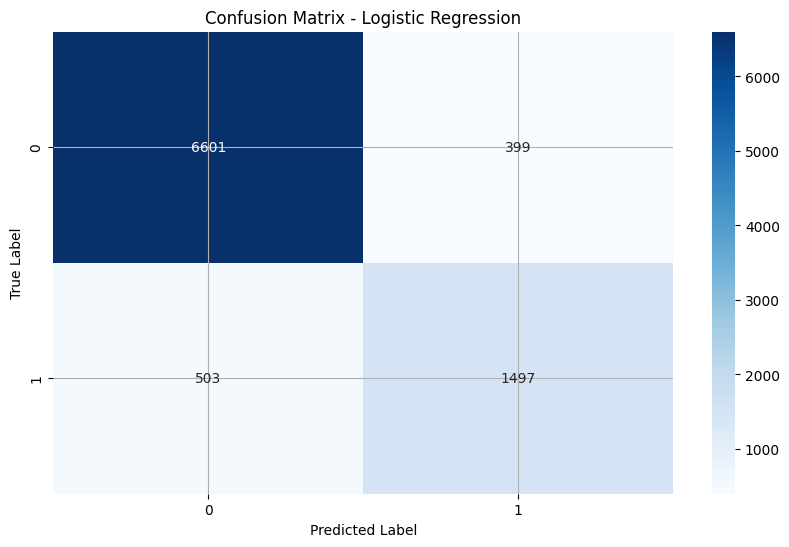

In [263]:

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [264]:
# TODO: SVM Classification

svm_model = SVC(
    kernel='rbf',
    random_state=42
)

# Train model
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [265]:
# Predict
y_pred_svm = svm_model.predict(X_test_scaled)


In [266]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.93      0.96      0.95      7000
           1       0.85      0.76      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.89      0.86      0.87      9000
weighted avg       0.91      0.92      0.91      9000



The model achieves 92% accuracy, which shows strong overall performance.For class 0, precision and recall are very high, meaning the model predicts this class very well.
For class 1, precision is good but recall is lower, so some positive cases are missed.

 F1 score 0.91 indicates a good balance between precision and recall considering class imbalance.

Overall the model performs well, but improving recall for class 1 could morw good performance.

## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



# Chosen Naive Bayes variant: Gaussian Naive Bayes, cause we have Continuous numeric dataset.


In [267]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)

print("Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_gnb))

Gaussian Naive Bayes:
              precision    recall  f1-score   support

           0       0.99      0.69      0.81      7000
           1       0.47      0.98      0.64      2000

    accuracy                           0.75      9000
   macro avg       0.73      0.83      0.73      9000
weighted avg       0.88      0.75      0.77      9000



## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


In [268]:
# TODO: KNN

k_values = range(1, 21)
accuracies = []

#multiple K values
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

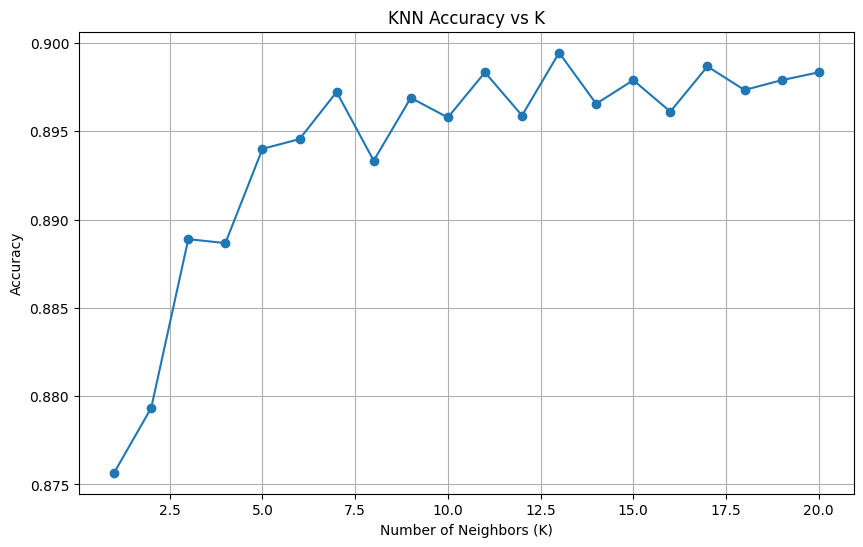

In [269]:
plt.figure(figsize=(10,6))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.grid(True)
plt.show()

## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [270]:
# TODO: Random Forest Classifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

#Train model
rf_clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [271]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf_clf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.9285555555555556


In [273]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head()


,Feature,Importance
21,previous_loan_defaults_on_file_Yes,0.218127
5,loan_percent_income,0.163793
4,loan_int_rate,0.157401
1,person_income,0.124549
3,loan_amnt,0.061482


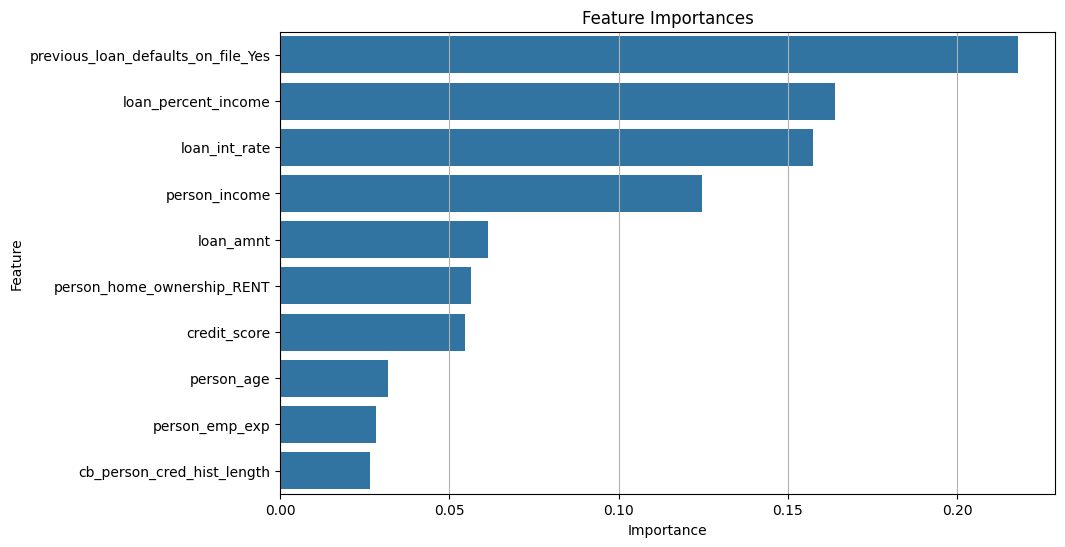

In [275]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Random Forest model gives high accuracy 92.855555555556%, so overall prediction is very good.Previous loan default, loan percent of income, and interest rate and so on the most important features.It means past loan behavior and financial burden play a big role in loan approval.

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## TODO: Write your reflection here
=> Best Regression Model is Polynomial Regression performed the best because it captured the non linear patterns in the insurance data better than Linear Regression and SVR.  R^2 score was higher and errors were lower.

=> Best Classification Model is Random Forest Classifier worked best since it gave the highest accuracy and handled feature interactions good. It was also more stable compared to other classifiers.

=> In real world use, these models can help companies quickly check customer risk, like predicting loan approval chances or estimating insurance costs, saving both time and money.